# 💼 Salary Data — Full Analysis Pipeline (Tech Jobs Focus)
**Dataset columns:** Age, Gender, Education Level, Job Title, Years of Experience, Salary

---
## Step 1: Load Dataset

In [8]:
import pandas as pd

df = pd.read_csv('Salary_Data.csv')

print(f'Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns')
df.head()

Dataset loaded: 6704 rows × 6 columns


,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


---
## Step 2: Basic EDA

In [3]:
# Shape
print('Shape:', df.shape)

# Column names
print('\nColumns:', df.columns.tolist())

Shape: (6704, 6)

Columns: ['Age', 'Gender', 'Education Level', 'Job Title', 'Years of Experience', 'Salary']


In [4]:
# Data types
print('Data Types:')
print(df.dtypes)

Data Types:
Age                    float64
Gender                  object
Education Level         object
Job Title               object
Years of Experience    float64
Salary                 float64
dtype: object


In [5]:
# Missing values — count + percentage
missing_count = df.isnull().sum()
missing_pct   = (missing_count / len(df) * 100).round(2)
missing_df    = pd.DataFrame({'Count': missing_count, 'Percent (%)': missing_pct})
print('Missing Values:')
missing_df

Missing Values:


,Count,Percent (%)
Age,2,0.03
Gender,2,0.03
Education Level,3,0.04
Job Title,2,0.03
Years of Experience,3,0.04
Salary,5,0.07


---
## Step 3: Data Cleaning

In [6]:
# Remove duplicates
before_dup = len(df)
df = df.drop_duplicates()
after_dup  = len(df)
print(f'Duplicates removed: {before_dup - after_dup}  ({before_dup} → {after_dup} rows)')

Duplicates removed: 4912  (6704 → 1792 rows)


In [9]:
# Strip whitespace from string columns
str_cols = df.select_dtypes(include='object').columns
df[str_cols] = df[str_cols].apply(lambda col: col.str.strip())

# Standardise Education Level labels
edu_map = {
    "Bachelor's Degree": "Bachelor's",
    "Master's Degree":   "Master's",
    "phd":               "PhD",
}
df['Education Level'] = df['Education Level'].replace(edu_map)
print('Education Level values after normalisation:')
print(df['Education Level'].value_counts())

Education Level values after normalisation:
Education Level
Bachelor's     3023
Master's       1861
PhD            1368
High School     448
phD               1
Name: count, dtype: int64


In [10]:
# Handle missing values
# Numeric  → fill with column median (no data leakage)
# Categoric → fill with mode
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include='object').columns

for col in num_cols:
    if df[col].isnull().any():
        med = df[col].median()
        df[col].fillna(med, inplace=True)
        print(f"  Filled '{col}' NaNs with median ({med})")

for col in cat_cols:
    if df[col].isnull().any():
        mode_val = df[col].mode()[0]
        df[col].fillna(mode_val, inplace=True)
        print(f"  Filled '{col}' NaNs with mode ('{mode_val}')")

print(f'\nRemaining missing values: {df.isnull().sum().sum()}')
print(f'Dataset shape after cleaning: {df.shape}')

  Filled 'Age' NaNs with median (32.0)
  Filled 'Years of Experience' NaNs with median (7.0)
  Filled 'Salary' NaNs with median (115000.0)
  Filled 'Gender' NaNs with mode ('Male')
  Filled 'Education Level' NaNs with mode ('Bachelor's')
  Filled 'Job Title' NaNs with mode ('Software Engineer')

Remaining missing values: 0
Dataset shape after cleaning: (6704, 6)


C:\Users\zeesh\AppData\Local\Temp\ipykernel_21016\2772724255.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(med, inplace=True)
C:\Users\zeesh\AppData\Local\Temp\ipykernel_21016\2772724255.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when do

---
## Step 4: Filter Tech Jobs Only

In [11]:
TECH_KEYWORDS = [
    'software', 'developer', 'data scientist', 'data analyst',
    'machine learning', 'ml engineer', 'ai engineer', 'data engineer',
    'devops', 'cloud', 'cybersecurity', 'network engineer',
    'systems engineer', 'database', 'it support', 'it manager',
    'web developer', 'backend', 'frontend', 'full stack',
    'computer', 'principal engineer', 'senior engineer',
    'chief technology', 'chief data', 'technical',
    'business intelligence', 'bi analyst', 'junior developer',
    'junior software', 'junior web', 'junior data',
    'senior software', 'senior data', 'senior engineer',
    'software project manager', 'software manager',
    'ux researcher', 'ux designer',
]

def is_tech(title: str) -> bool:
    t = title.lower()
    return any(kw in t for kw in TECH_KEYWORDS)

rows_before = len(df)
tech_df     = df[df['Job Title'].apply(is_tech)].copy().reset_index(drop=True)
rows_after  = len(tech_df)

print(f'Rows BEFORE filter : {rows_before}')
print(f'Rows AFTER  filter : {rows_after}  ({rows_before - rows_after} non-tech rows removed)')
print(f'\nUnique tech job titles retained: {tech_df["Job Title"].nunique()}')
print(sorted(tech_df['Job Title'].unique()))

Rows BEFORE filter : 6704
Rows AFTER  filter : 3267  (3437 non-tech rows removed)

Unique tech job titles retained: 43
['Back end Developer', 'Business Intelligence Analyst', 'Chief Data Officer', 'Chief Technology Officer', 'Data Analyst', 'Data Scientist', 'Developer', 'Front End Developer', 'Front end Developer', 'Full Stack Engineer', 'IT Manager', 'IT Support', 'IT Support Specialist', 'Junior Data Analyst', 'Junior Data Scientist', 'Junior Developer', 'Junior Software Developer', 'Junior Software Engineer', 'Junior UX Designer', 'Junior Web Designer', 'Junior Web Developer', 'Network Engineer', 'Principal Engineer', 'Senior Data Analyst', 'Senior Data Engineer', 'Senior Data Scientist', 'Senior Engineer', 'Senior IT Support Specialist', 'Senior Software Architect', 'Senior Software Developer', 'Senior Software Engineer', 'Senior UX Designer', 'Software Developer', 'Software Engineer', 'Software Engineer Manager', 'Software Manager', 'Software Project Manager', 'Technical Recruite

---
## Step 5: Visualisations

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style='whitegrid', palette='muted')

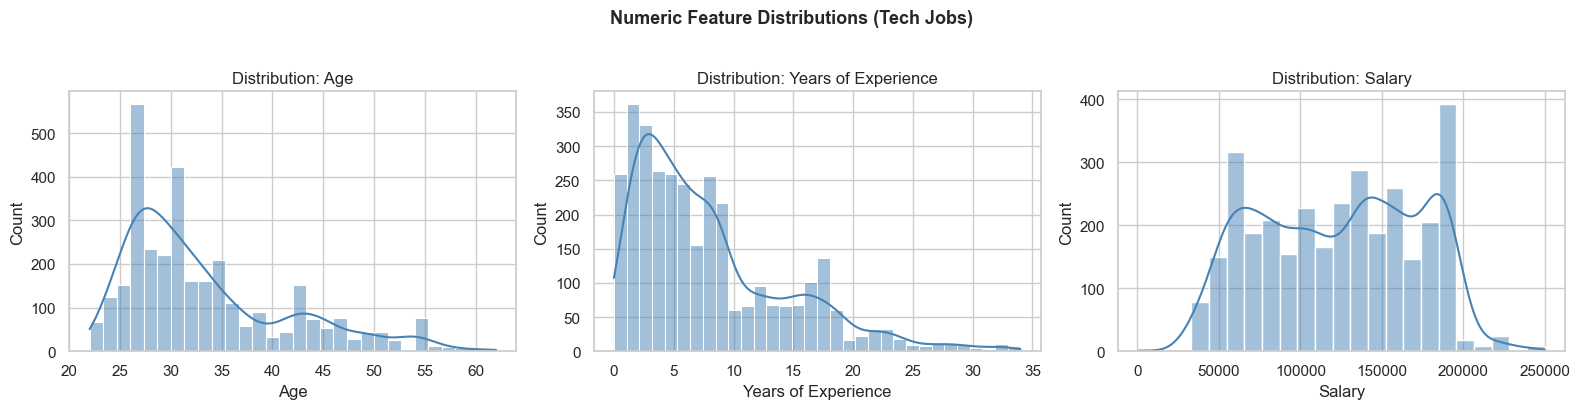

In [13]:
# Histograms for numeric columns
num_features = ['Age', 'Years of Experience', 'Salary']

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, num_features):
    sns.histplot(tech_df[col], kde=True, ax=ax, color='steelblue')
    ax.set_title(f'Distribution: {col}')
plt.suptitle('Numeric Feature Distributions (Tech Jobs)', y=1.02, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('hist_numeric.png', dpi=120, bbox_inches='tight')
plt.show()

C:\Users\zeesh\AppData\Local\Temp\ipykernel_21016\3533867632.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


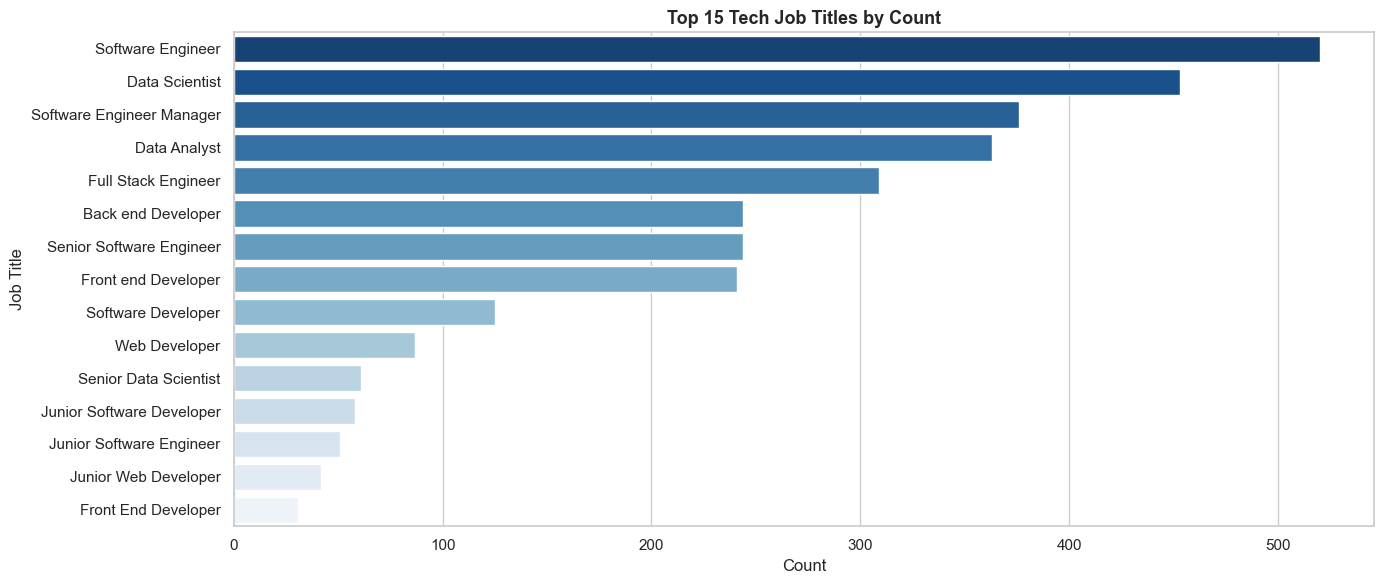

In [14]:
# Count plot — top 15 tech job titles
top_titles = tech_df['Job Title'].value_counts().head(15).index

fig, ax = plt.subplots(figsize=(14, 6))
sns.countplot(
    data=tech_df[tech_df['Job Title'].isin(top_titles)],
    y='Job Title',
    order=top_titles,
    palette='Blues_r',
    ax=ax,
)
ax.set_title('Top 15 Tech Job Titles by Count', fontsize=13, fontweight='bold')
ax.set_xlabel('Count')
plt.tight_layout()
plt.savefig('countplot_jobs.png', dpi=120, bbox_inches='tight')
plt.show()

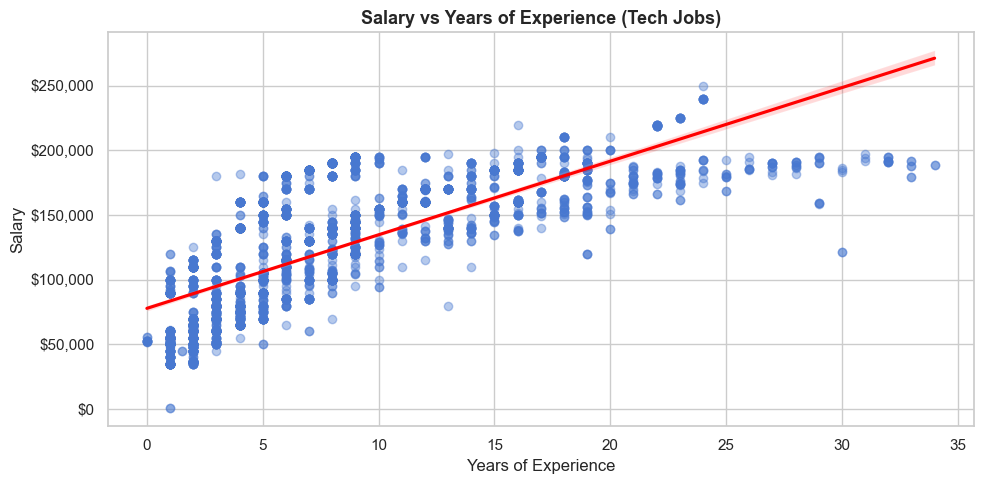

Correlation: 0.7560


In [18]:
# Salary trend vs Experience (scatter + regression line)
fig, ax = plt.subplots(figsize=(10, 5))
sns.regplot(data=tech_df, x='Years of Experience', y='Salary', 
            scatter_kws={'alpha': 0.4}, line_kws={'color': 'red'}, ax=ax)
ax.set_title('Salary vs Years of Experience (Tech Jobs)', fontsize=13, fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

print(f"Correlation: {tech_df['Years of Experience'].corr(tech_df['Salary']):.4f}")

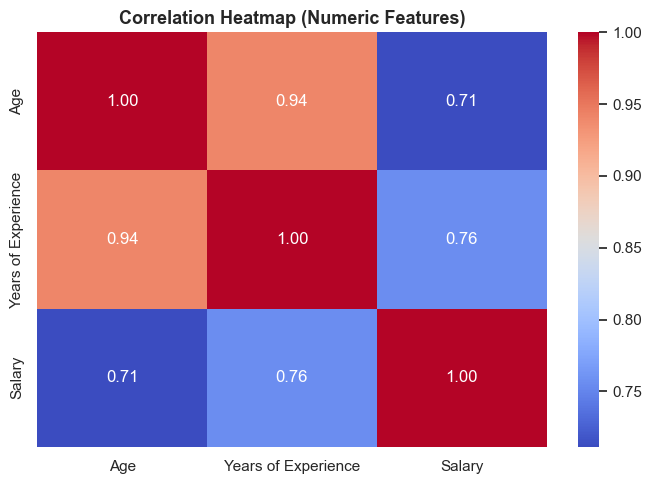

In [15]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(7, 5))
corr = tech_df[num_features].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax)
ax.set_title('Correlation Heatmap (Numeric Features)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('heatmap_corr.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Step 6: Feature Engineering

In [16]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

fe_df = tech_df.copy()

# Create binary target: 1 = salary at/above median, 0 = below median
salary_median = fe_df['Salary'].median()
fe_df['Salary_Class'] = (fe_df['Salary'] >= salary_median).astype(int)
print(f"Salary median: {salary_median:,.0f}")
print('Target distribution:')
print(fe_df['Salary_Class'].value_counts())

Salary median: 130,000
Target distribution:
Salary_Class
1    1640
0    1627
Name: count, dtype: int64


In [17]:
# Label encode categorical columns
le_gender  = LabelEncoder()
le_edu     = LabelEncoder()
le_title   = LabelEncoder()

fe_df['Gender_enc']    = le_gender.fit_transform(fe_df['Gender'])
fe_df['Education_enc'] = le_edu.fit_transform(fe_df['Education Level'])
fe_df['JobTitle_enc']  = le_title.fit_transform(fe_df['Job Title'])

print('Gender encoding  :', dict(zip(le_gender.classes_, le_gender.transform(le_gender.classes_))))
print('Education encoding:', dict(zip(le_edu.classes_, le_edu.transform(le_edu.classes_))))

Gender encoding  : {'Female': np.int64(0), 'Male': np.int64(1), 'Other': np.int64(2)}
Education encoding: {"Bachelor's": np.int64(0), 'High School': np.int64(1), "Master's": np.int64(2), 'PhD': np.int64(3)}


In [19]:
# Build feature matrix and scale numeric columns
FEATURES = ['Age', 'Years of Experience', 'Gender_enc', 'Education_enc', 'JobTitle_enc']
TARGET   = 'Salary_Class'

X = fe_df[FEATURES].copy()
y = fe_df[TARGET].copy()

scaler = StandardScaler()
X[['Age', 'Years of Experience']] = scaler.fit_transform(X[['Age', 'Years of Experience']])

print(f'Feature matrix shape : {X.shape}')
print(f'Target vector shape  : {y.shape}')
X.head()

Feature matrix shape : (3267, 5)
Target vector shape  : (3267,)


,Age,Years of Experience,Gender_enc,Education_enc,JobTitle_enc
0,-0.158614,-0.468822,1,0,33
1,-0.650725,-0.779720,0,2,4
2,-0.527697,-0.779720,1,2,32
3,0.702580,0.619322,1,3,26
4,-0.404670,-0.935169,1,0,11


---
## Step 7: Model Building

In [20]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

print(f'Train set : {X_train.shape[0]} rows')
print(f'Test  set : {X_test.shape[0]} rows')

Train set : 2613 rows
Test  set : 654 rows


In [21]:
# Random Forest with regularisation to reduce overfitting
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
)
model.fit(X_train, y_train)

# 5-fold cross-validation
cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
print(f'5-Fold CV Accuracy : {cv_scores.mean():.4f}  ± {cv_scores.std():.4f}')
print(f'CV scores per fold : {cv_scores.round(4)}')

5-Fold CV Accuracy : 0.9514  ± 0.0108
CV scores per fold : [0.956  0.9503 0.9598 0.9598 0.931 ]


---
## Step 8: Evaluation

In [22]:
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

y_pred = model.predict(X_test)

print(f'Test Accuracy : {accuracy_score(y_test, y_pred):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['Below Median', 'At/Above Median']))

Test Accuracy : 0.9557

Classification Report:
                 precision    recall  f1-score   support

   Below Median       0.95      0.96      0.96       326
At/Above Median       0.96      0.95      0.96       328

       accuracy                           0.96       654
      macro avg       0.96      0.96      0.96       654
   weighted avg       0.96      0.96      0.96       654



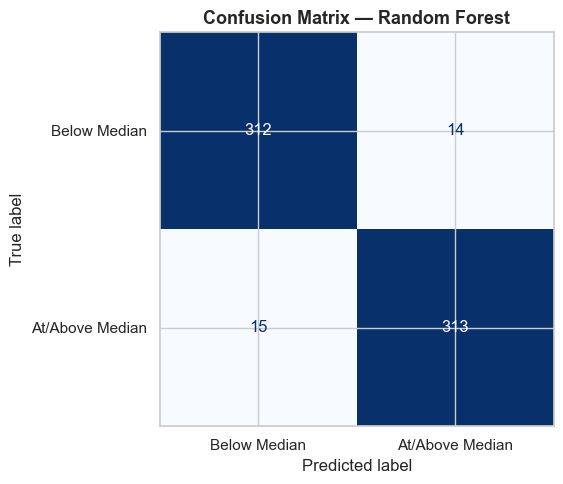

In [23]:
# Confusion Matrix
cm  = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Below Median', 'At/Above Median'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Random Forest', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

C:\Users\zeesh\AppData\Local\Temp\ipykernel_21016\2769699511.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis', ax=ax)


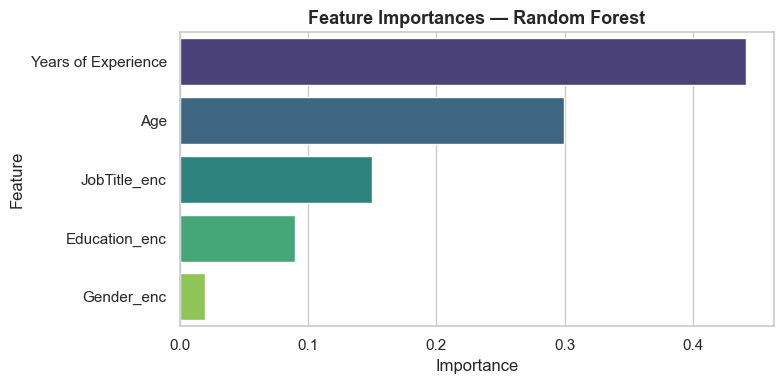

            Feature  Importance
Years of Experience    0.441286
                Age    0.299208
       JobTitle_enc    0.150150
      Education_enc    0.089688
         Gender_enc    0.019667


In [24]:
# Feature Importances
importance_df = pd.DataFrame({
    'Feature':    FEATURES,
    'Importance': model.feature_importances_,
}).sort_values('Importance', ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis', ax=ax)
ax.set_title('Feature Importances — Random Forest', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(importance_df.to_string(index=False))

---
## Step 9: Save Files

In [25]:
import pickle

# Save cleaned tech dataset
tech_df.to_csv('tech_jobs_cleaned.csv', index=False)
print('✅ Saved: tech_jobs_cleaned.csv')

# Save trained model
with open('tech_job_model.pkl', 'wb') as f:
    pickle.dump(model, f)
print('✅ Saved: tech_job_model.pkl')

print('\n🎉 Pipeline complete. All outputs saved successfully.')

✅ Saved: tech_jobs_cleaned.csv
✅ Saved: tech_job_model.pkl

🎉 Pipeline complete. All outputs saved successfully.


In [26]:
import pickle
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

# ── Use tech_df from Step 4 (already filtered & cleaned) ──
reg_df = tech_df.copy()

# ── Encode categorical columns ────────────────────────────
le_gender = LabelEncoder()
le_edu    = LabelEncoder()
le_title  = LabelEncoder()

reg_df['Gender_enc']    = le_gender.fit_transform(reg_df['Gender'])
reg_df['Education_enc'] = le_edu.fit_transform(reg_df['Education Level'])
reg_df['JobTitle_enc']  = le_title.fit_transform(reg_df['Job Title'])

print('Gender classes   :', list(le_gender.classes_))
print('Education classes:', list(le_edu.classes_))
print('Job title count  :', len(le_title.classes_))

# ── Features & Target ─────────────────────────────────────
FEATURES = ['Age', 'Years of Experience', 'Gender_enc', 'Education_enc', 'JobTitle_enc']
TARGET   = 'Salary'

X = reg_df[FEATURES].copy()
y = reg_df[TARGET].copy()

# ── Scale numeric columns ─────────────────────────────────
scaler = StandardScaler()
X[['Age', 'Years of Experience']] = scaler.fit_transform(X[['Age', 'Years of Experience']])

# ── Train / Test Split ────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)
print(f'Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows')

# ── Train Regressor ───────────────────────────────────────
reg_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=4,
    random_state=42,
    n_jobs=-1
)
reg_model.fit(X_train, y_train)

# ── Evaluate ──────────────────────────────────────────────
y_pred = reg_model.predict(X_test)
print(f'MAE : ${mean_absolute_error(y_test, y_pred):,.0f}')
print(f'R2  : {r2_score(y_test, y_pred):.4f}')

# ── Save bundle (model + encoders + scaler + job list) ────
bundle = {
    'model'     : reg_model,
    'scaler'    : scaler,
    'le_gender' : le_gender,
    'le_edu'    : le_edu,
    'le_title'  : le_title,
    'tech_jobs' : sorted(reg_df['Job Title'].unique().tolist()),
    'genders'   : sorted(reg_df['Gender'].unique().tolist()),
    'edu_levels': sorted(reg_df['Education Level'].unique().tolist()),
}

with open('tech_job_model.pkl', 'wb') as f:
    pickle.dump(bundle, f)

print('\n✅ Saved: tech_job_model.pkl  — ready for Streamlit app!')

Gender classes   : ['Female', 'Male', 'Other']
Education classes: ["Bachelor's", 'High School', "Master's", 'PhD']
Job title count  : 43
Train: 2613 rows | Test: 654 rows
MAE : $6,467
R2  : 0.9376

✅ Saved: tech_job_model.pkl  — ready for Streamlit app!
